# Projekt Dyplomowy 2026

**Autor:** Paweł Myszka 331720

**Temat:** Wyznaczanie poziomów Fibonacciego pod kątem możliwego zastosowania w modelach klasyfikacyjnych (lasy losowe).

# 1. Wczytanie potrzebnych bibliotek

In [404]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
from scipy.signal import argrelextrema
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 2. Pobranie danych giełodwych i uporządkowanie data frame.

In [405]:
ticker = ("aapl")  # symbol dnaego indeksu, np. "AAPL", "^GSPC", "ETH-USD"
okres  = "10y"       # 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
interwal = "1d"     # 1m, 5m, 15m, 1h, 1d, 1wk, 1mo

df = yf.download(ticker, period=okres, interval=interwal)
df.columns = df.columns.get_level_values(0) 
df = df.reset_index()
df.columns.name = None

print(df.head())

[*********************100%***********************]  1 of 1 completed

        Date      Close       High        Low       Open     Volume
0 2016-03-31  24.684105  24.890203  24.659192  24.849436  103553600
1 2016-04-01  24.910583  24.912849  24.505183  24.636542  103496000
2 2016-04-04  25.166513  25.408848  24.974004  25.007976  149424800
3 2016-04-05  24.869822  25.078185  24.781494  24.801878  106314800
4 2016-04-06  25.130272  25.134802  24.731666  24.964942  105616400


**Przetwarzanie data frame:**

1 Usunięcie podowojnych nagłówków (yfinance zwraca wielopoziomowe kolumny, gydbyśmy chcieli pobrać więcej niż jeden indeks).

2 Ustawienie date jako kolumny a nie jako indeks

3 Price ustawia się jako id- usuwamy to aby tabela wyglądała czysto

**Opis pobranych danych:**

Open- cena otwarcia świecy

High — najwyższa cena w ciągu dnia

Low — najniższa cena w ciągu dnia

Close — cena zamknięcia świecy (na końcu dnia)

Volume — wolumen, czyli ile BTC zostało sprzedane w ciągu dnia

**Wstępne wiadomości o pobranych danych**

In [406]:
print(f"Liczba rekordów: {len(df)}")
print(f"Zakres dat: {df['Date'].min()} — {df['Date'].max()}")
print(f"\nBrakujące wartości:")
print(df.isnull().sum())
print(f"\nTypy danych:")
print(df.dtypes)

Liczba rekordów: 2514
Zakres dat: 2016-03-31 00:00:00 — 2026-03-30 00:00:00

Brakujące wartości:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Typy danych:
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object


# Wizualizacja wykresu

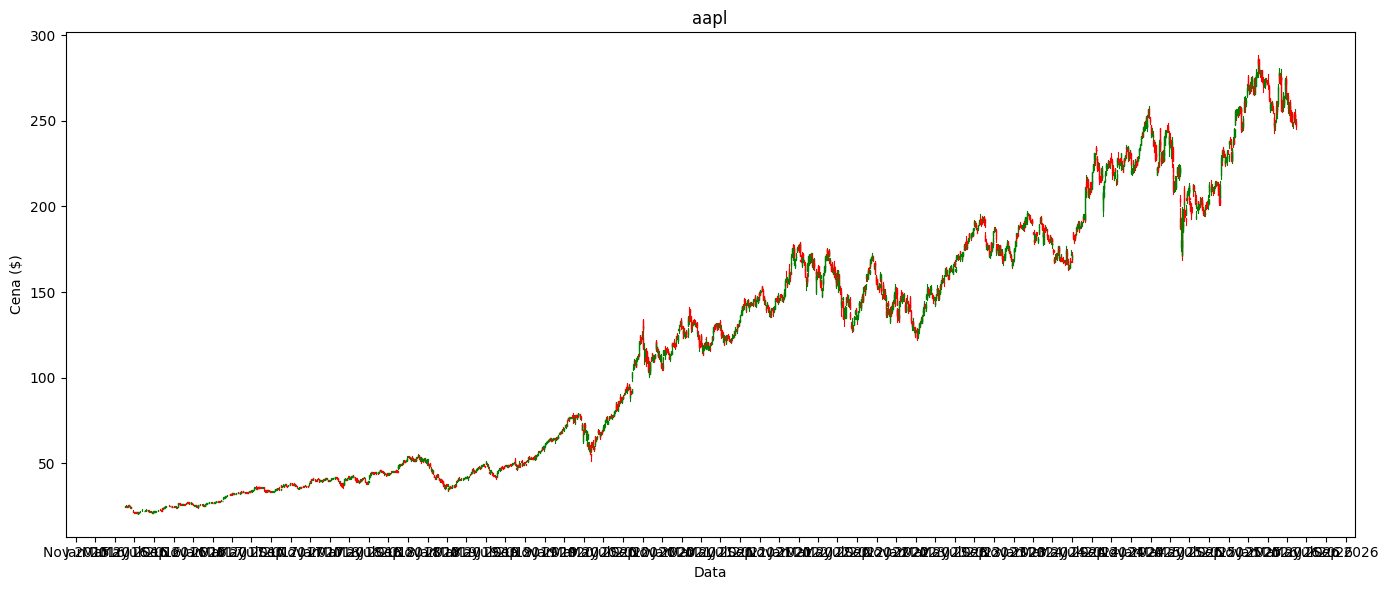

In [407]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Sprawdzenie lokalnych punktów min/max

In [408]:
n = 5 #ile swiec sprawdzamy z kazdej strony
df["swing_high"] = np.nan
df["swing_low"] = np.nan

df.loc[argrelextrema(df["High"].values, np.greater_equal, order=n)[0], "swing_high"] = df["High"] # znajdowanie numery wieszy lokalnyh maks
df.loc[argrelextrema(df["Low"].values, np.less_equal, order=n)[0], "swing_low"] = df["Low"] # znajdowanie numery wieszy lokalnyh min

print(f"Swing high: {df['swing_high'].notna().sum()}")
print(f"Swing low:  {df['swing_low'].notna().sum()}")

Swing high: 139
Swing low:  137


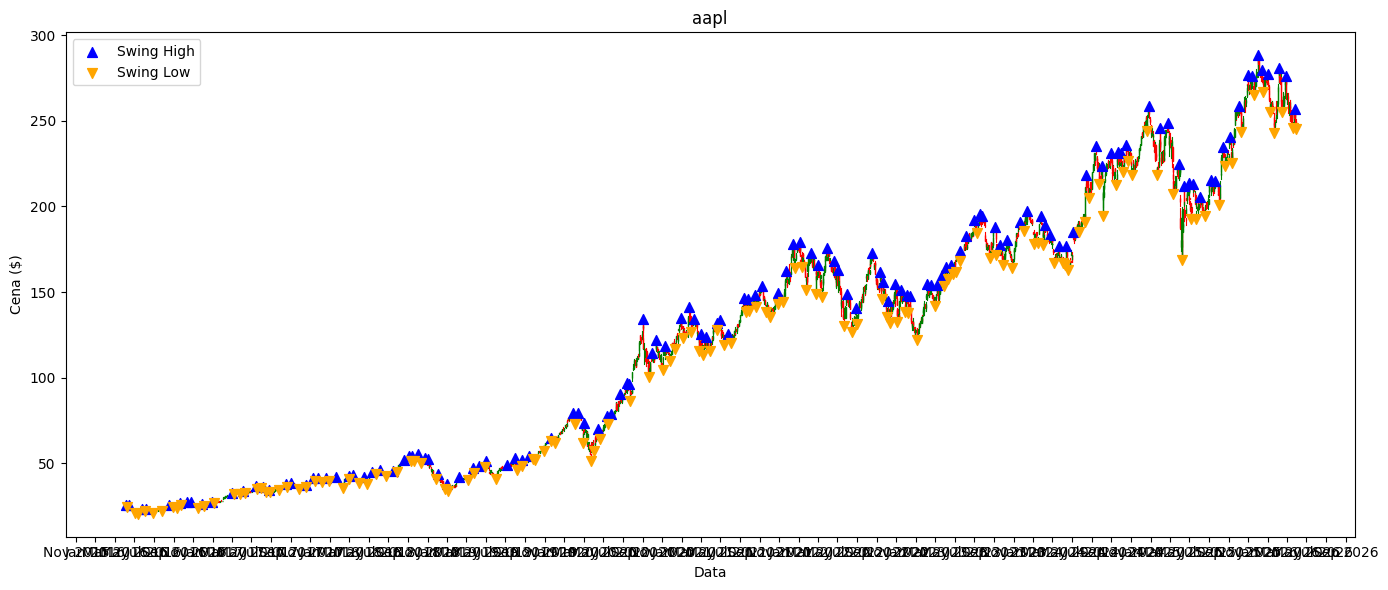

In [409]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Wyznaczenie lini trendów

In [410]:
swing_points = []

for i, row in df.iterrows():
    if not np.isnan(row["swing_high"]):
        swing_points.append((row["Date"], row["swing_high"], "high"))
    if not np.isnan(row["swing_low"]):
        swing_points.append((row["Date"], row["swing_low"], "low"))

swing_points.sort(key=lambda x: x[0])

trends = []
for i in range(len(swing_points) - 1):
    a, b = swing_points[i], swing_points[i + 1]
    if a[2] == "low" and b[2] == "high":
        trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "wzrost"})
    elif a[2] == "high" and b[2] == "low":
        trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "spadek"})

print(f"Liczba trendów: {len(trends)}")

Liczba trendów: 229


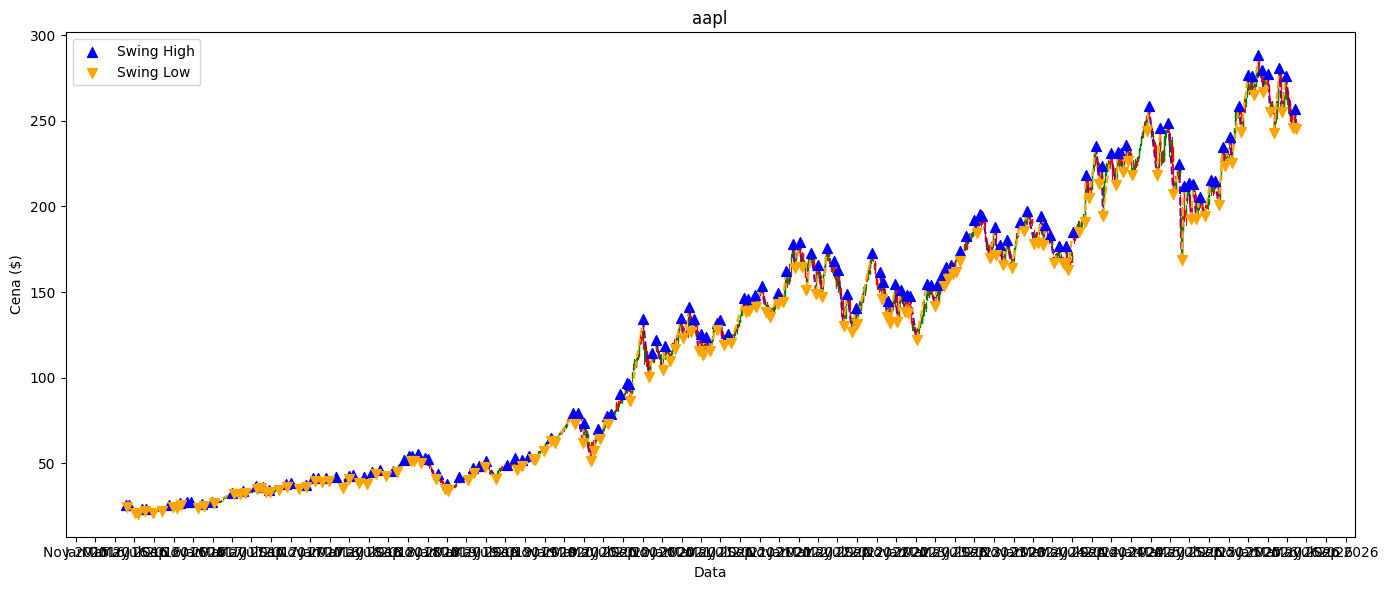

In [411]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()
for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Wyznaczanie poziomów fibonnaciego

In [412]:
LEVELS = [0, 0.38, 0.5, 0.61, 0.707, 0.878, 1, 1.272, 1.618, 2.058, 2.618, 0.8, 0.236, 0.44, 0.577, 0.667, 0.786, 0.941, 1.13, 1.414, 1.732, 2.236, 0.278, 0.77]
#LEVELS = [0.236, 0.382, 0.5, 0.618, 0.786]
fib_zones = []

for t in trends:
    high = t["end_price"] if t["typ"] == "wzrost" else t["start_price"]
    low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]
    
    for level in LEVELS:
        price = high - (high - low) * level
        fib_zones.append({
            "start_date": t["start_date"],
            "end_date":   t["end_date"],
            "level":      level,
            "price":      price,
            "typ":        t["typ"]
        })

print(f"Liczba stref: {len(fib_zones)}")
print(fib_zones[:3])

Liczba stref: 5496
[{'start_date': Timestamp('2016-04-04 00:00:00'), 'end_date': Timestamp('2016-04-07 00:00:00'), 'level': 0, 'price': 25.408847505611973, 'typ': 'spadek'}, {'start_date': Timestamp('2016-04-04 00:00:00'), 'end_date': Timestamp('2016-04-07 00:00:00'), 'level': 0.38, 'price': 25.058571362094934, 'typ': 'spadek'}, {'start_date': Timestamp('2016-04-04 00:00:00'), 'end_date': Timestamp('2016-04-07 00:00:00'), 'level': 0.5, 'price': 24.947957843089554, 'typ': 'spadek'}]


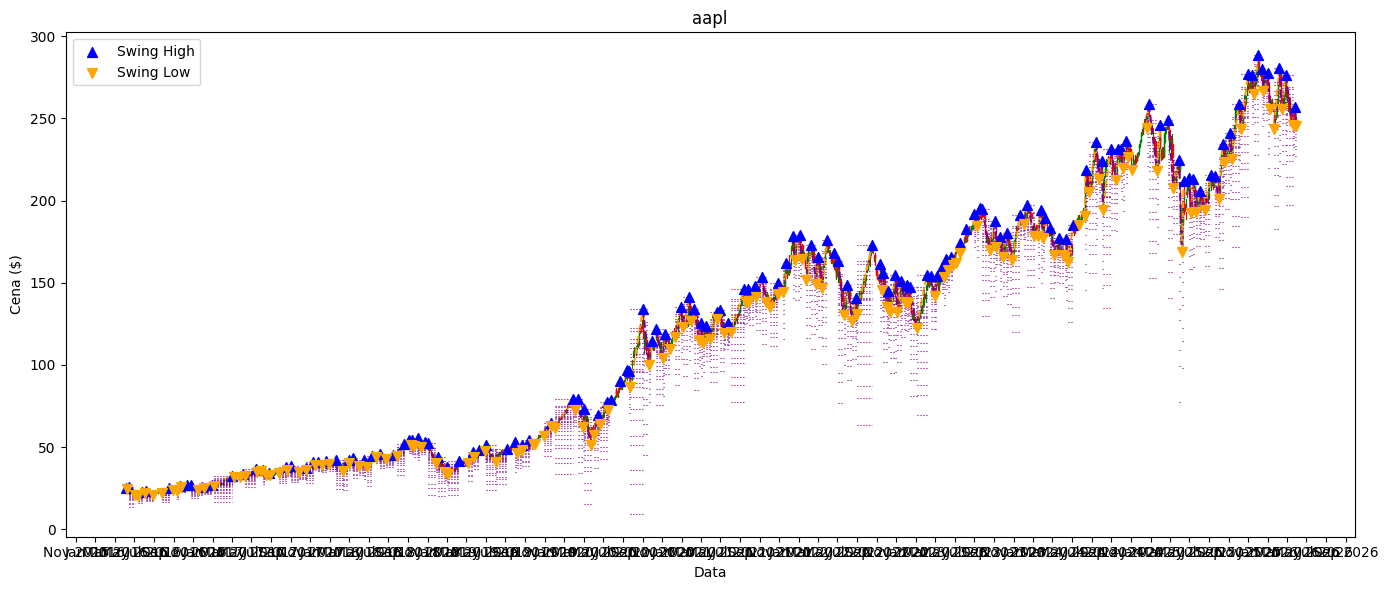

In [413]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones:
    ax.hlines(z["price"], z["start_date"], z["end_date"], 
              colors="purple", linewidth=0.8, linestyle=":")
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Agregacja stref

In [414]:
N_TRENDOW = 3
N_SWIEC   = 20
tolerance = 0.02

def agreguj_strefy(poziomy_z_levelami, tolerance):
    """
    poziomy_z_levelami: lista krotek (cena, level)
    Zwraca: lista krotek (srednia_cena, dominujacy_level)
    """
    poziomy_z_levelami = sorted(poziomy_z_levelami, key=lambda x: x[0])
    grupy  = []
    grupa  = [poziomy_z_levelami[0]]

    for p in poziomy_z_levelami[1:]:
        if (p[0] - grupa[-1][0]) / grupa[-1][0] < tolerance:
            grupa.append(p)
        else:
            dom_level = Counter([x[1] for x in grupa]).most_common(1)[0][0]
            grupy.append((np.mean([x[0] for x in grupa]), dom_level))
            grupa = [p]

    dom_level = Counter([x[1] for x in grupa]).most_common(1)[0][0]
    grupy.append((np.mean([x[0] for x in grupa]), dom_level))
    return grupy


fib_zones_new = []

for i in range(N_TRENDOW, len(trends)):
    ostatnie_trendy = trends[i - N_TRENDOW:i]

    poziomy = []  # lista krotek (cena, level)
    for t in ostatnie_trendy:
        high = t["end_price"]   if t["typ"] == "wzrost" else t["start_price"]
        low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]
        for level in LEVELS:
            poziomy.append((high - (high - low) * level, level))

    grupy = agreguj_strefy(poziomy, tolerance)

    end_date = trends[i]["end_date"]
    future   = df[df["Date"] > end_date]["Date"]
    line_end = future.iloc[N_SWIEC - 1] if len(future) >= N_SWIEC else df["Date"].iloc[-1]

    for cena, level in grupy:
        fib_zones_new.append({
            "price":       cena,
            "level":       level,   # <── teraz jest!
            "start":       end_date,
            "end":         line_end,
            "typ":         trends[i]["typ"],
            "trend_idx":   i,
            "trend_start": trends[i]["start_date"],
            "trend_end":   trends[i]["end_date"],
        })

print(f"Liczba stref: {len(fib_zones_new)}")

Liczba stref: 1319


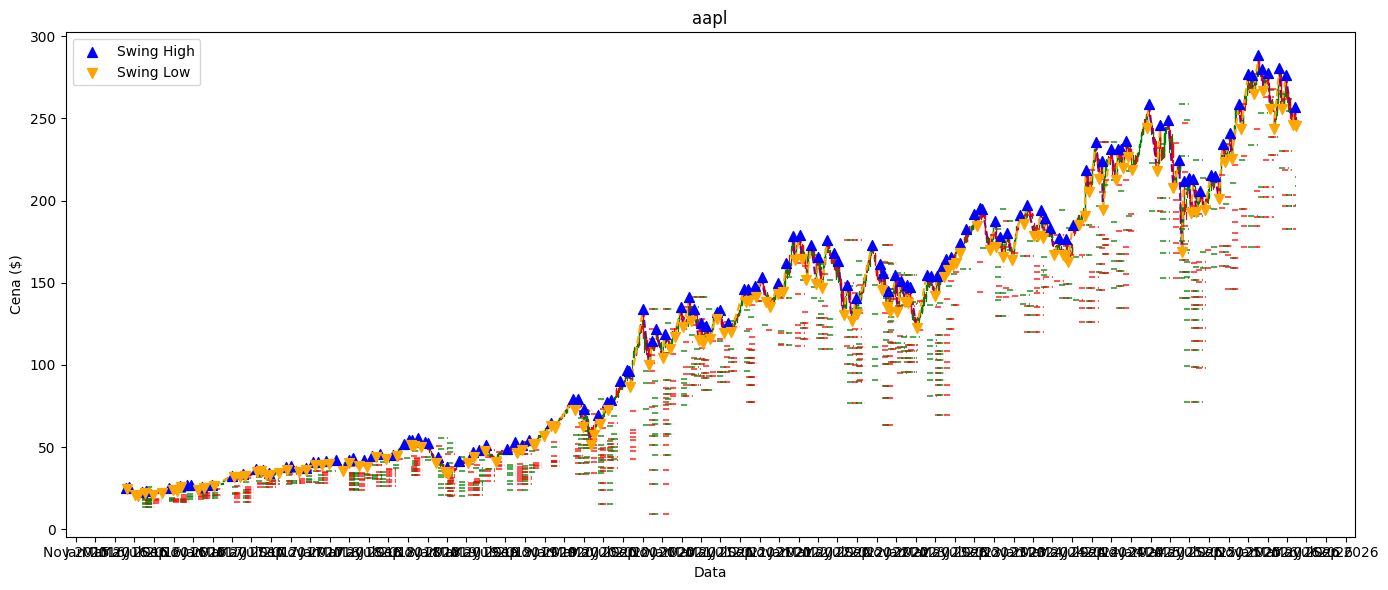

In [397]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones_new:
    kolor = "green" if z["typ"] == "wzrost" else "red"
    ax.hlines(z["price"], z["start"], z["end"],
              colors=kolor, linewidth=1.2, linestyle="--", alpha=0.8)
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Etykietowanie stref

In [398]:
TOLERANCJA_ODBICIA = 0.02  # 2% - tolerancja dotknięcia strefy
MIN_ODBICIE        = 0.03  # 3% - minimalny ruch żeby uznać za odbicie
N_SWIEC_ODBICIE    = 5     # ile świec po dotknięciu sprawdzamy

def etykietuj_strefy(fib_zones_new, df):
    for z in fib_zones_new:
        swiece = df[(df["Date"] > z["start"]) & (df["Date"] <= z["end"])].copy()

        trafiona     = False
        data_odbicia = None

        for idx, s in swiece.iterrows():
            # Krok 1: czy cena dotknęła strefy?
            if abs(s["Close"] - z["price"]) / z["price"] < TOLERANCJA_ODBICIA:

                # Krok 2: sprawdź kolejne N świec czy nastąpiło odbicie
                swiece_po = df[df["Date"] > s["Date"]].iloc[:N_SWIEC_ODBICIE]

                if len(swiece_po) == 0:
                    break

                cena_dotkniecia = s["Close"]

                if z["typ"] == "spadek":
                    # strefa wsparcia – oczekujemy wzrostu po odbiciu
                    max_po = swiece_po["Close"].max()
                    if (max_po - cena_dotkniecia) / cena_dotkniecia >= MIN_ODBICIE:
                        trafiona     = True
                        data_odbicia = s["Date"]
                else:
                    # strefa oporu – oczekujemy spadku po odbiciu
                    min_po = swiece_po["Close"].min()
                    if (cena_dotkniecia - min_po) / cena_dotkniecia >= MIN_ODBICIE:
                        trafiona     = True
                        data_odbicia = s["Date"]
                break  # sprawdzamy tylko pierwsze dotknięcie

        z["etykieta"]    = "trafiona" if trafiona else "nietrafiona"
        z["data_odbicia"] = data_odbicia

    return fib_zones_new

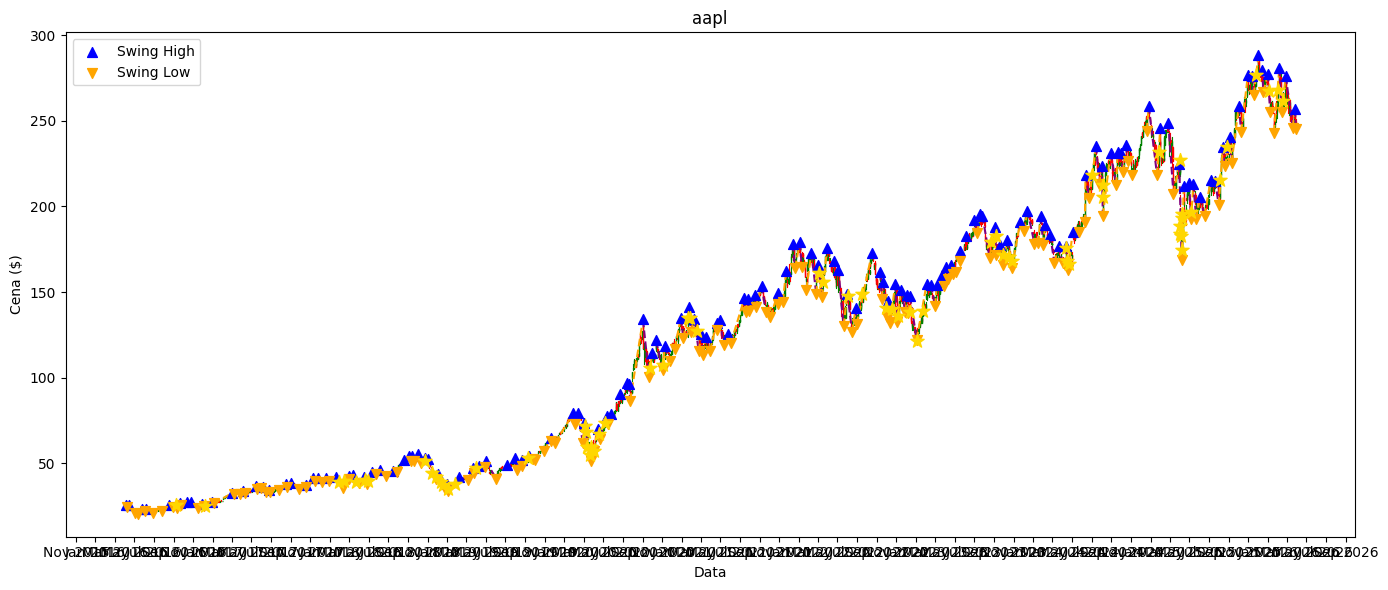

In [399]:
fib_zones_new = etykietuj_strefy(fib_zones_new, df)

fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
ax.legend()

for t in trends:
    color = "orange" if t["typ"] == "wzrost" else "purple"
    ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]], 
            color=color, linewidth=1.5, linestyle="--")
    
for z in fib_zones_new:
    if z["etykieta"] == "trafiona" and z["data_odbicia"] is not None:
        ax.scatter(z["data_odbicia"], z["price"], 
                   color="gold", marker="*", s=100, zorder=6)
    
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()

# Generowanie cech dla modelu 

In [400]:
def generuj_cechy(fib_zones_new, df, trends):
    dane = []

    def oblicz_rsi(series, okres=14):
        delta = series.diff()
        gain = delta.clip(lower=0).rolling(okres).mean()
        loss = (-delta.clip(upper=0)).rolling(okres).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def oblicz_atr(df, okres=14):
        hl = df["High"] - df["Low"]
        hc = (df["High"] - df["Close"].shift()).abs()
        lc = (df["Low"]  - df["Close"].shift()).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        return tr.rolling(okres).mean()

    df = df.copy()
    df["RSI"]   = oblicz_rsi(df["Close"])
    df["ATR"]   = oblicz_atr(df)
    df["SMA20"] = df["Close"].rolling(20).mean()
    df["SMA50"] = df["Close"].rolling(50).mean()

    for z in fib_zones_new:
        swiece = df[(df["Date"] > z["start"]) & (df["Date"] <= z["end"])]
        if len(swiece) == 0:
            continue

        df_przed = df[df["Date"] <= z["start"]]
        if len(df_przed) < 25:
            continue
        close_start = df_przed["Close"].iloc[-1]

        trend = next((t for t in trends if t["end_date"] == z["start"]), None)
        if trend is None:
            continue

        df_trend       = df[(df["Date"] >= trend["start_date"]) & (df["Date"] <= trend["end_date"])]
        dlugosc_trendu = len(df_trend)
        zmiana_trendu  = (trend["end_price"] - trend["start_price"]) / trend["start_price"]

        rsi_wejscie = df_przed["RSI"].iloc[-1]
        atr_wejscie = df_przed["ATR"].iloc[-1]
        sma20       = df_przed["SMA20"].iloc[-1]
        sma50       = df_przed["SMA50"].iloc[-1]
        trend_sma   = 1 if sma20 > sma50 else 0

        poziom_fib = z["level"]

        ilosc_w_klastrze = sum(
            1 for other in fib_zones_new
            if other["trend_idx"] == z["trend_idx"]
            and abs(other["price"] - z["price"]) / z["price"] < 0.02
        )

        vol_ostatnie5    = df_przed["Volume"].iloc[-5:].mean()
        vol_srednia_hist = df_przed["Volume"].iloc[-25:-5].mean()
        vol_relatywny    = vol_ostatnie5 / vol_srednia_hist if vol_srednia_hist > 0 else 1.0

        odleglosc_od_sma20 = (z["price"] - sma20) / sma20 if sma20 > 0 else 0

        atr_sredni_trend = df_trend["ATR"].mean()
        zmiennosc_trendu = atr_sredni_trend / trend["end_price"] if trend["end_price"] > 0 else 0

        # nowe cechy – TUTAJ, po df_przed i rsi_wejscie
        momentum5  = (df_przed["Close"].iloc[-1] - df_przed["Close"].iloc[-6]) / df_przed["Close"].iloc[-6]
        rsi_strefa = 1 if rsi_wejscie < 35 else (-1 if rsi_wejscie > 65 else 0)

        dane.append({
            "odleglosc_od_strefy": (close_start - z["price"]) / z["price"],
            "wolumen_sredni":       vol_ostatnie5,
            "wolumen_w_trendzie":   df_trend["Volume"].mean(),
            "dlugosc_trendu":       dlugosc_trendu,
            "zmiana_trendu":        zmiana_trendu,
            "typ_trendu":           1 if z["typ"] == "wzrost" else 0,
            "poziom_fib":           poziom_fib,
            "ilosc_w_klastrze":     ilosc_w_klastrze,
            "vol_relatywny":        vol_relatywny,
            "rsi_wejscie":          rsi_wejscie,
            "atr_wejscie":          atr_wejscie,
            "trend_sma":            trend_sma,
            "odleglosc_od_sma20":   odleglosc_od_sma20,
            "zmiennosc_trendu":     zmiennosc_trendu,
            "momentum5":            momentum5,
            "rsi_strefa":           rsi_strefa,
            "etykieta":             1 if z["etykieta"] == "trafiona" else 0
        })

    return pd.DataFrame(dane)


df_model = generuj_cechy(fib_zones_new, df, trends)
print(df_model.head())
print(f"\nRozkład etykiet:\n{df_model['etykieta'].value_counts()}")
print(f"\nLiczba cech: {df_model.shape[1] - 1}")
print(f"\nBrakujące wartości:\n{df_model.isnull().sum()}")

   odleglosc_od_strefy  wolumen_sredni  wolumen_w_trendzie  dlugosc_trendu  \
0             0.682115     159747840.0        1.822085e+08              11   
1             0.492360     159747840.0        1.822085e+08              11   
2             0.417833     159747840.0        1.822085e+08              11   
3             0.299021     159747840.0        1.822085e+08              11   
4             0.262039     159747840.0        1.822085e+08              11   

   zmiana_trendu  typ_trendu  poziom_fib  ilosc_w_klastrze  vol_relatywny  \
0       0.125852           1       2.618                 1       0.794413   
1       0.125852           1       2.236                 1       0.794413   
2       0.125852           1       2.058                 1       0.794413   
3       0.125852           1       1.732                 1       0.794413   
4       0.125852           1       1.618                 1       0.794413   

   rsi_wejscie  atr_wejscie  trend_sma  odleglosc_od_sma20  zmiennos

# Podział cech

In [401]:
X = df_model.drop(columns=["etykieta"])
#X = df_model.drop(columns=["etykieta", "odleglosc_od_strefy", "odleglosc_od_sma20"])
y = df_model["etykieta"]

# chronologiczny podział 80/20
split = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Treningowy: {len(X_train)} próbek")
print(f"Testowy:    {len(X_test)} próbek")

Treningowy: 1052 próbek
Testowy:    263 próbek


# Trening i ocena modelu

In [402]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

modele = {
    "Random Forest":        (RandomForestClassifier(n_estimators=100, random_state=42,
                                                    class_weight='balanced', min_samples_leaf=5), X_train, X_test),
    "Drzewo decyzyjne":     (DecisionTreeClassifier(random_state=42,
                                                    class_weight='balanced'), X_train, X_test),
    "SVM":                  (SVC(random_state=42,
                                 class_weight='balanced'), X_train_scaled, X_test_scaled),
    "Regresja logistyczna": (LogisticRegression(random_state=42,
                                                class_weight='balanced'), X_train_scaled, X_test_scaled),
}

for nazwa, (model, X_tr, X_te) in modele.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    cm = confusion_matrix(y_test, y_pred)
    print(f"{'='*50}")
    print(f"{nazwa}")
    print(f"  Dokładność : {accuracy_score(y_test, y_pred):.2f}")
    print(f"  F1-score   : {f1_score(y_test, y_pred, zero_division=0):.2f}")
    print(f"  Macierz pomyłek:")
    print(f"    [[TN={cm[0,0]:>4}  FP={cm[0,1]:>4}]")
    print(f"     [FN={cm[1,0]:>4}  TP={cm[1,1]:>4}]]")
    print()
    print(classification_report(y_test, y_pred,
                                target_names=["nietrafiona", "trafiona"],
                                zero_division=0))

Random Forest
  Dokładność : 0.90
  F1-score   : 0.14
  Macierz pomyłek:
    [[TN= 236  FP=   8]
     [FN=  17  TP=   2]]

              precision    recall  f1-score   support

 nietrafiona       0.93      0.97      0.95       244
    trafiona       0.20      0.11      0.14        19

    accuracy                           0.90       263
   macro avg       0.57      0.54      0.54       263
weighted avg       0.88      0.90      0.89       263

Drzewo decyzyjne
  Dokładność : 0.92
  F1-score   : 0.00
  Macierz pomyłek:
    [[TN= 243  FP=   1]
     [FN=  19  TP=   0]]

              precision    recall  f1-score   support

 nietrafiona       0.93      1.00      0.96       244
    trafiona       0.00      0.00      0.00        19

    accuracy                           0.92       263
   macro avg       0.46      0.50      0.48       263
weighted avg       0.86      0.92      0.89       263

SVM
  Dokładność : 0.88
  F1-score   : 0.31
  Macierz pomyłek:
    [[TN= 225  FP=  19]
     [FN= 

# Sprawdzenie ważności cech

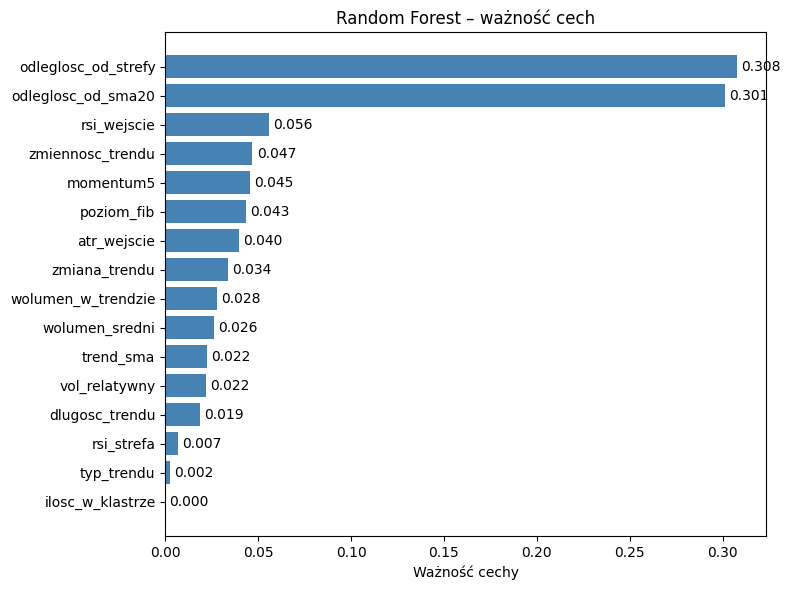

In [403]:
rf_model = modele["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(importances.index, importances.values, color="steelblue")
ax.set_xlabel("Ważność cechy")
ax.set_title("Random Forest – ważność cech")
ax.bar_label(bars, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

### TO DO

PODODAWANIE WIEKSZEJ ILOSCI wolumenow ZEBY MIEC WIECJE INFO DO MODELU

Zwiekszyc F1 score

DOROBIC WROZENIE Z FUSOW JEZELI BEDZIE GIT- przewidywanie przyslzosci jezlei dobrze wytrenujemy model